--- Problem 1: Omitted Variable Bias ---

--- Running simulation with N=100 (Small Sample) ---
True coefficient for X (b_true): 2
Estimated coefficient for X (Full Model, N=100): 2.1192
Estimated coefficient for X (Omitted Model, N=100): 3.3990

--- Running simulation with N=10000 (Large Sample) ---
True coefficient for X (b_true): 2
Estimated coefficient for X (Full Model, N=10000): 2.0014
Estimated coefficient for X (Omitted Model, N=10000): 3.5061

--- Problem 2: Sensitivity to Outliers ---

--- Baseline Model (No Outliers) ---
True Intercept (Beta0): 10, True Slope (Beta1): 0.5
Estimated Intercept: 10.7298, Estimated Slope: 0.4824
R-squared: 0.8794

--- Model with Outlier ---
Estimated Intercept: 4.9951, Estimated Slope: 0.6370
R-squared: 0.3088


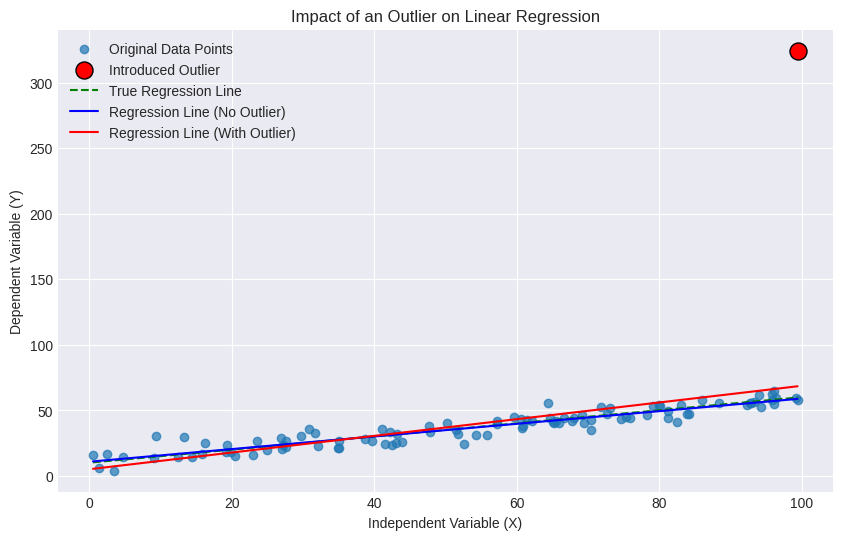


--- Problem 3: Model Selection ---
Loaded data (hardcoded) for Problem 3:
          Y       Z1         Z2        Z3        Z4        Z5
0  2.172296  0.121634 -0.051562  0.570616  1.279931  0.075233
1  0.502380  0.025446 -0.093062  0.304875 -0.582292  0.377388
2  0.711362 -0.136716 -0.082229 -0.191680 -0.647970  1.230986
3 -0.557168 -0.284459 -0.170922 -0.853670 -1.256146 -0.991686
4  1.500199  0.105205 -0.169141  0.826558  0.640945  1.099873

Dataset columns after renaming: ['y', 'x1', 'x2', 'x3', 'x4', 'x5']

--- Model Selection: Backward Elimination (Optimizing Adjusted R-squared) ---
Initial Full Model: Predictors ['x1', 'x2', 'x3', 'x4', 'x5'], Adjusted R-squared: 0.9936
  No further improvement in Adjusted R-squared by removing any predictor.

Final Best Model by Backward Elimination (Adjusted R-squared): ['x1', 'x2', 'x3', 'x4', 'x5']

--- Model Selection: Forward Selection (Minimizing AIC) ---
Initial Null Model: Predictors [], AIC: 334.0103
  Added 'x4'. New AIC: 141.1442. Cur

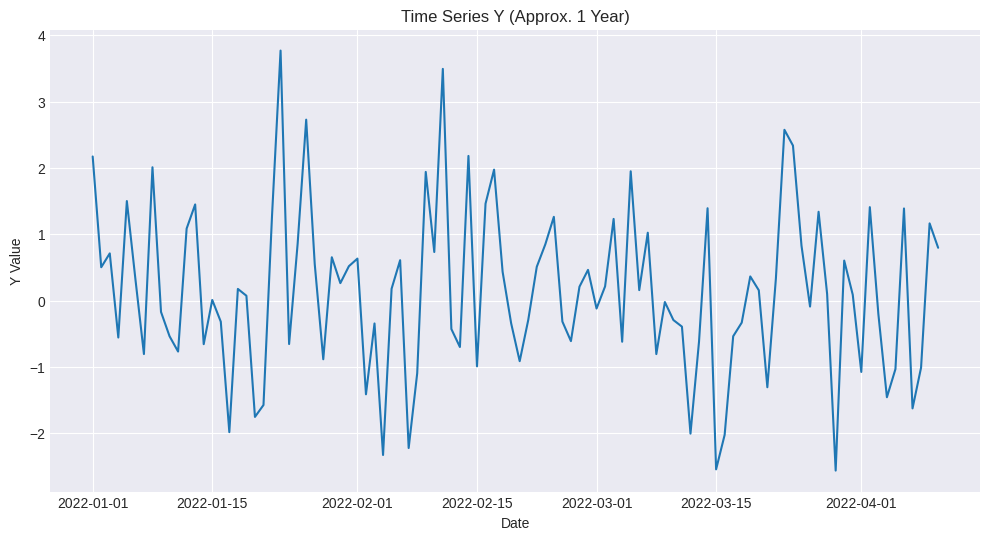


--- ADF Test for Stationarity ---
ADF Statistic: -4.961
p-value: 0.000
Critical Values:
   1%: -3.500
   5%: -2.892
   10%: -2.583
Result: The series is stationary (reject H0)
Series is already stationary (or became stationary with d=0).


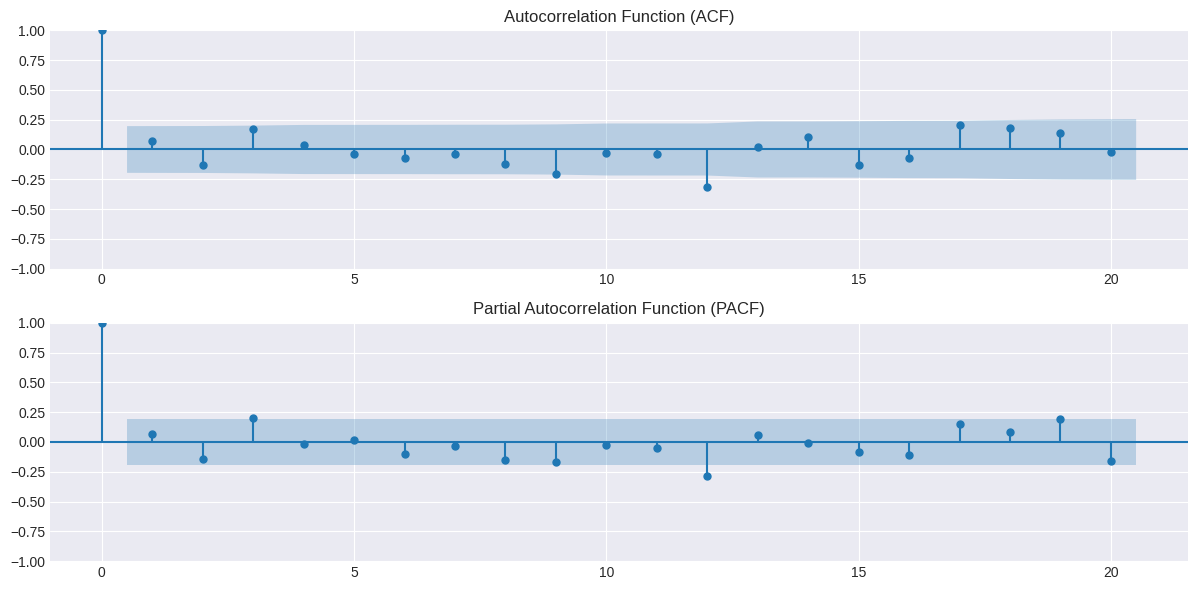


--- Manually Chosen ARIMA Order (p,d,q): (1, 0, 0) ---
Note: p and q are chosen manually. Inspect the ACF/PACF plots above to refine these values if necessary.
Given the problem description and lack of auto_arima, (1, d, 0) is a reasonable default for many financial series.

--- Fitting ARIMA Model with order (1, 0, 0) ---
                               SARIMAX Results                                
Dep. Variable:               y_values   No. Observations:                   80
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -131.872
Date:                Wed, 11 Jun 2025   AIC                            269.744
Time:                        09:00:31   BIC                            276.891
Sample:                    01-01-2022   HQIC                           272.609
                         - 03-21-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


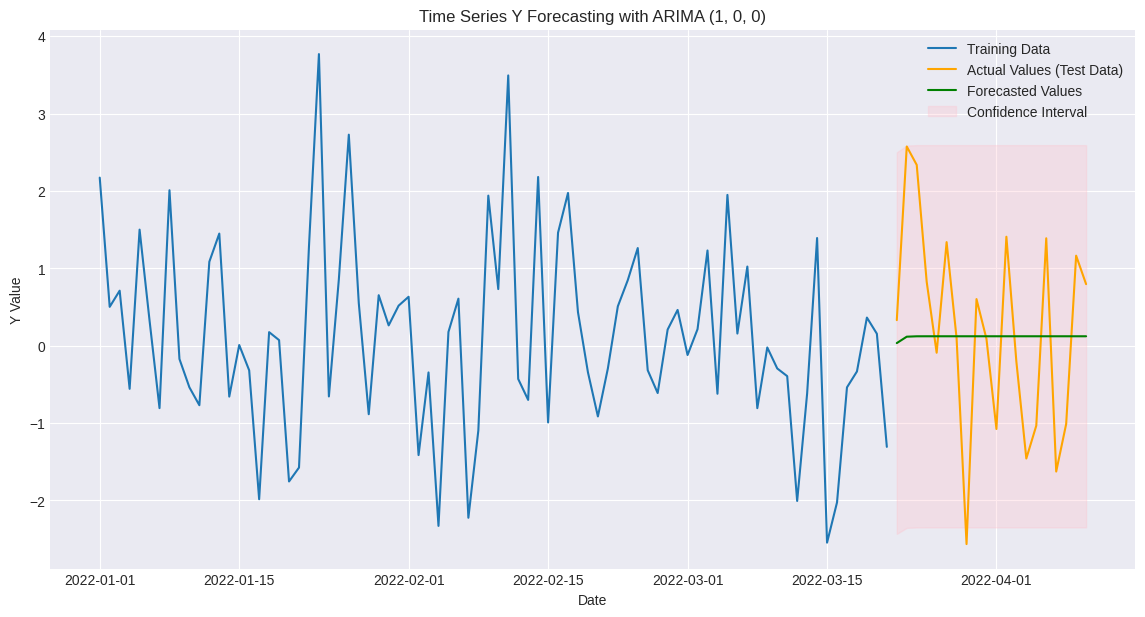


RMSE (Root Mean Squared Error) on Test Data: 1.323

--- Problem 6: Structural Break ---
--- Hardcoded Data for Problem 6 (20 periods with simulated structural break) ---
     t          Y          X  D        X_D
0    1  11.962363  10.993428  0   0.000000
1    2   9.635959   9.723471  0   0.000000
2    3  10.715217  11.295377  0   0.000000
3    4  10.098282  13.046060  0   0.000000
4    5   9.221464   9.531693  0   0.000000
5    6   9.876786   9.531726  0   0.000000
6    7  10.428219  13.158426  0   0.000000
7    8  11.143133  11.534869  0   0.000000
8    9   8.929887   9.061051  0   0.000000
9   10  10.250866  11.085120  0   0.000000
10  11  18.008040   9.073165  1   9.073165
11  12  20.455089   9.068540  1   9.068540
12  13  20.712390  10.483925  1  10.483925
13  14  13.202448   6.173440  1   6.173440
14  15  15.647791   6.550164  1   6.550164
15  16  17.092294   8.875425  1   8.875425
16  17  17.170370   7.974338  1   7.974338
17  18  18.983072  10.628495  1  10.628495
18  19  15.9

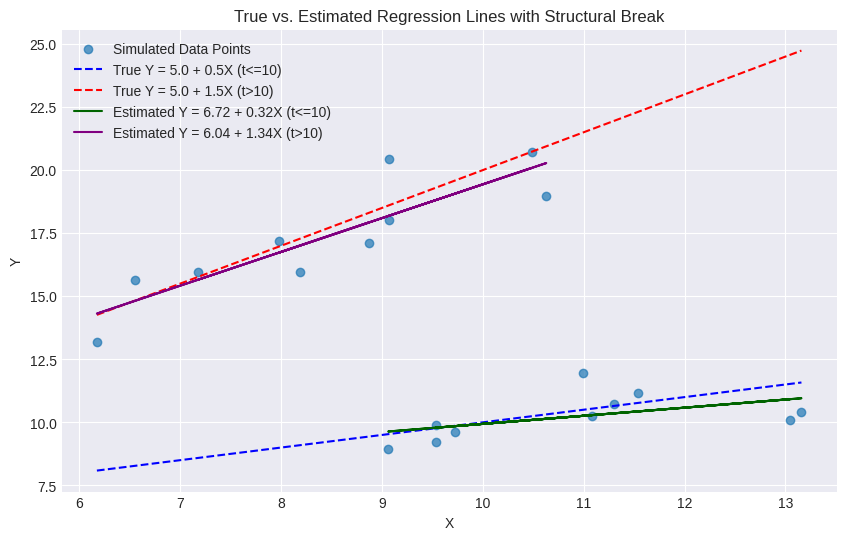

In [2]:
# =============================================================================
# MScFE 610 FINANCIAL ECONOMETRICS - Group Work Project #1
# Python Code Submission
# =============================================================================

# --- Import Libraries ---
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import summary_table
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf # For Problem 5b

# --- Global Settings (Optional but good practice) ---
plt.rcParams['figure.figsize'] = (10, 6) # Default plot size
plt.style.use('seaborn-v0_8-darkgrid') # A nice plot style for plots
np.random.seed(42) # For reproducibility of simulations

# =============================================================================
# Problem 1: Omitted Variable Bias (Simulations)
# =============================================================================

print("--- Problem 1: Omitted Variable Bias ---")

# 1d) Simulation for Omitted Variable Bias

# Define true parameters for the simulation
a_true = 5      # True intercept
b_true = 2      # True coefficient for X
c_true = 3      # True coefficient for Z (the omitted variable)

# Sample sizes for demonstration
n_samples_small = 100   # Small sample size
n_samples_large = 10000 # Large sample size to show convergence/persistence of bias

# --- Simulation Function ---
def run_omitted_variable_simulation(n_samples, b_true_val, c_true_val, correlation_level='medium'):
    """
    Runs a single simulation to demonstrate omitted variable bias.
    Generates X and Z with specified correlation, then Y based on a true model.
    Estimates a full model (Y ~ X + Z) and an omitted model (Y ~ X).
    Compares the estimated coefficient for X in both cases.
    """

    # 1. Generate X from a normal distribution
    X = np.random.normal(loc=50, scale=10, size=n_samples)

    # 2. Generate Z such that it is correlated with X
    # The 'k_corr' parameter controls the strength of correlation between X and Z.
    # 'noise_z_scale' controls the randomness in Z, influencing correlation.
    if correlation_level == 'high':
        k_corr = 0.8
        noise_z_scale = 2
    elif correlation_level == 'low':
        k_corr = 0.1
        noise_z_scale = 8
    else: # 'medium' correlation by default
        k_corr = 0.5
        noise_z_scale = 5

    noise_z = np.random.normal(loc=0, scale=noise_z_scale, size=n_samples)
    Z = k_corr * X + noise_z # Z is a linear function of X plus some independent noise

    # 3. Generate Error Term (epsilon) independently of X and Z
    # This error term is part of the true model.
    epsilon = np.random.normal(loc=0, scale=5, size=n_samples) # Standard deviation of 5

    # 4. Generate Y using the true regression model: Y(i) = a + b*X(i) + c*Z(i) + epsilon(i)
    Y = a_true + b_true_val * X + c_true_val * Z + epsilon

    # --- Estimation ---

    # Model 1: Full Model (correctly specified: Y ~ X + Z)
    # Adding a constant (intercept) to the design matrix
    X_full_model = sm.add_constant(pd.DataFrame({'X': X, 'Z': Z}))
    model_full = sm.OLS(Y, X_full_model).fit()
    b_full_estimated = model_full.params['X'] # Extract the coefficient for X

    # Model 2: Omitted Model (erroneously specified: Y ~ X, omitting Z)
    X_omitted_model = sm.add_constant(pd.DataFrame({'X': X}))
    model_omitted = sm.OLS(Y, X_omitted_model).fit()
    b_omitted_estimated = model_omitted.params['X'] # Extract the coefficient for X

    # Return the estimated coefficients for X and the model summaries for analysis
    return b_full_estimated, b_omitted_estimated, model_full.summary(), model_omitted.summary()

# --- Run Simulations for Small Sample Size ---
print(f"\n--- Running simulation with N={n_samples_small} (Small Sample) ---")
b_full_small, b_omitted_small, summary_full_small, summary_omitted_small = \
    run_omitted_variable_simulation(n_samples_small, b_true, c_true, correlation_level='medium')

print(f"True coefficient for X (b_true): {b_true}")
print(f"Estimated coefficient for X (Full Model, N={n_samples_small}): {b_full_small:.4f}")
print(f"Estimated coefficient for X (Omitted Model, N={n_samples_small}): {b_omitted_small:.4f}")

# You can print these summaries in your technical report if needed for detailed analysis
# print("\nFull Model Summary (Small Sample):")
# print(summary_full_small.as_text())
# print("\nOmitted Model Summary (Small Sample):")
# print(summary_omitted_small.as_text())


# --- Run Simulations for Large Sample Size ---
print(f"\n--- Running simulation with N={n_samples_large} (Large Sample) ---")
b_full_large, b_omitted_large, summary_full_large, summary_omitted_large = \
    run_omitted_variable_simulation(n_samples_large, b_true, c_true, correlation_level='medium')

print(f"True coefficient for X (b_true): {b_true}")
print(f"Estimated coefficient for X (Full Model, N={n_samples_large}): {b_full_large:.4f}")
print(f"Estimated coefficient for X (Omitted Model, N={n_samples_large}): {b_omitted_large:.4f}")

# The purpose of using large N is to show that the omitted model's estimate for b
# will converge to a biased value, while the full model's estimate will converge to the true value.


# =============================================================================
# Problem 2: Sensitivity to Outliers (Simulations)
# =============================================================================

print("\n--- Problem 2: Sensitivity to Outliers ---")

# 2b) Simulate and Illustrate Outlier Impact

# Define true parameters for a simple linear regression
true_beta0 = 10  # True intercept
true_beta1 = 0.5 # True slope
n_observations = 100 # Number of data points

# 1. Generate Baseline Data (Data without any outliers)
X_baseline = np.random.uniform(0, 100, n_observations) # Independent variable
epsilon_baseline = np.random.normal(0, 5, n_observations) # Random error term with small std dev
Y_baseline = true_beta0 + true_beta1 * X_baseline + epsilon_baseline # Dependent variable

# Estimate regression model on the baseline data
X_baseline_const = sm.add_constant(X_baseline) # Add intercept term to X
model_baseline = sm.OLS(Y_baseline, X_baseline_const).fit()

print(f"\n--- Baseline Model (No Outliers) ---")
print(f"True Intercept (Beta0): {true_beta0}, True Slope (Beta1): {true_beta1}")
print(f"Estimated Intercept: {model_baseline.params[0]:.4f}, Estimated Slope: {model_baseline.params[1]:.4f}")
print(f"R-squared: {model_baseline.rsquared:.4f}")

# 2. Introduce an Outlier into a copy of the baseline data
X_data_with_outlier = np.copy(X_baseline)
Y_data_with_outlier = np.copy(Y_baseline)

# To demonstrate impact, we choose a point and significantly alter its Y value.
# We'll pick an observation with a high X value to make it an "influential" outlier.
# An influential outlier has high leverage (unusual X) AND high discrepancy (unusual Y for that X).
outlier_idx = np.argmax(X_data_with_outlier) # Index of the observation with the largest X value
# Make the Y value of this observation significantly higher than expected
Y_data_with_outlier[outlier_idx] = Y_data_with_outlier[outlier_idx] * 3 + 150
# The multiplier (3) and additive constant (150) are arbitrary to create a visible outlier

# Estimate regression model with the outlier
X_outlier_const = sm.add_constant(X_data_with_outlier)
model_with_outlier = sm.OLS(Y_data_with_outlier, X_outlier_const).fit()

print(f"\n--- Model with Outlier ---")
print(f"Estimated Intercept: {model_with_outlier.params[0]:.4f}, Estimated Slope: {model_with_outlier.params[1]:.4f}")
print(f"R-squared: {model_with_outlier.rsquared:.4f}")

# --- Plotting to illustrate the impact of the outlier ---
plt.figure(figsize=(10, 6))
# Plot original data points (excluding the modified outlier point visually, as it's separate)
plt.scatter(X_baseline, Y_baseline, label='Original Data Points', alpha=0.7)
# Highlight the outlier point with a distinct color and size
plt.scatter(X_data_with_outlier[outlier_idx], Y_data_with_outlier[outlier_idx],
            color='red', s=150, edgecolor='black', zorder=5, label='Introduced Outlier')

# Plot the true regression line
x_plot_vals = np.array([min(X_baseline), max(X_baseline)])
plt.plot(x_plot_vals, true_beta0 + true_beta1 * x_plot_vals,
         color='green', linestyle='--', label='True Regression Line')

# Plot the regression line from the baseline model (no outliers)
plt.plot(x_plot_vals, model_baseline.params[0] + model_baseline.params[1] * x_plot_vals,
         color='blue', label='Regression Line (No Outlier)')

# Plot the regression line from the model with the outlier
plt.plot(x_plot_vals, model_with_outlier.params[0] + model_with_outlier.params[1] * x_plot_vals,
         color='red', label='Regression Line (With Outlier)')

plt.title('Impact of an Outlier on Linear Regression')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y)')
plt.legend()
plt.grid(True)
plt.show()


# =============================================================================
# Problem 3: Model Selection
# =============================================================================

print("\n--- Problem 3: Model Selection ---")

# 3a) Model Selection using a few approaches

# --- Data Hardcoded from FE-GWP1_model_selection_2.csv ---
# The data is hardcoded as requested. This eliminates the need for file reading.
# This data was extracted from 'FE-GWP1_model_selection_2.csv'
hardcoded_data = {
    'Y': [2.172295694, 0.502379785, 0.71136223, -0.557167994, 1.500198906, 0.325555554, -0.806494404, 2.009625043, -0.17134099, -0.537861283, -0.768796632, 1.085117233, 1.4493227, -0.657341068, 0.009114673, -0.318255932, -1.983655041, 0.175555769, 0.072617763, -1.754158527, -1.574529036, 1.281364047, 3.76865263, -0.655530409, 0.858960861, 2.727395479, 0.551653714, -0.885037251, 0.653038863, 0.262786543, 0.517950175, 0.632663056, -1.413208264, -0.345108507, -2.328180526, 0.178100044, 0.608142455, -2.223180512, -1.095442938, 1.93962268, 0.731923859, 3.492810393, -0.429322138, -0.700231862, 2.180611836, -0.991552331, 1.460733094, 1.973578737, 0.434108033, -0.3429446, -0.913934669, -0.294401754, 0.50887552, 0.847366176, 1.262384095, -0.316668214, -0.611345172, 0.208807003, 0.462556683, -0.120146867, 0.213590718, 1.230896874, -0.620722588, 1.949056002, 0.157411953, 1.022987203, -0.806774449, -0.022382697, -0.293776724, -0.393094405, -2.006060824, -0.617825921, 1.391790535, -2.544610844, -2.024801531, -0.538138522, -0.332662073, 0.363733278, 0.154883715, -1.306901761, 0.330713, 2.574409061, 2.336578452, 0.826299475, -0.090417456, 1.338689674, 0.098863812, -2.563219954, 0.602431706, 0.088348321, -1.076115809, 1.408425388, -0.203017492, -1.457690477, -1.033066844, 1.388461697, -1.625616975, -1.011110898, 1.163815973, 0.795845521],
    'Z1 ': [0.121633899, 0.025445543, -0.136715863, -0.284459313, 0.105205363, 0.120766116, -0.021073185, -0.239805996, -0.041596538, -0.235357772, 0.149251006, 0.149125263, 0.058967366, 0.06885219, 0.219453141, 0.157911619, 0.001665079, 0.052522806, 0.308767326, -0.189396899, -0.002881013, -0.009088376, 0.226299754, -0.037254493, -0.042612383, -0.057084017, 0.044614326, 0.275986529, 0.149415009, -0.407934055, -0.331701296, 0.222268187, -0.288116549, 0.080141487, 0.155268418, -0.090128657, -0.241134704, 0.054759484, 0.077114815, 0.043654436, 0.259778594, 0.146845725, -0.295569751, -0.105260517, -0.098059529, -0.052165154, 0.012720338, -0.022931495, -0.047009695, 0.024688339, 0.127247494, -0.213077996, 0.241909115, -0.358519312, -0.113680427, 0.087256241, -0.20940187, 0.157544906, 0.34484031, -0.174404563, -0.218415174, -0.037895635, 0.339809868, -8.05859e-05, 0.00088184, 0.164885469, 0.004677911, -0.046184597, -0.153521789, -0.042126213, 0.051701301, -0.08742074, 0.01616938, -0.235333312, 0.058669432, -0.216202851, -0.091858647, -0.083958258, 0.344143885, -0.022687532, -0.098751722, 0.020106645, -0.306681653, -0.118506662, -0.238301511, -0.062552472, 0.360024067, 0.112892202, -0.417517117, 0.131706971, -0.134580399, 0.276340886, 0.244825744, 0.314806452, -0.220438315, -0.087479887, -0.038310045, 0.10562909, 0.220918352, -0.10381085],
    'Z2': [-0.0515623, -0.093062463, -0.082228758, -0.170922251, -0.169141028, -0.497594194, -0.217212467, -0.352480657, 0.280601165, 0.221527112, 0.555395854, 0.249683788, -0.42610293, 0.356568699, -0.105480582, 0.246767002, 0.25965691, 0.339665635, -0.45206818, 0.056972269, -0.757017292, 0.406714147, 0.170169461, 0.070645539, -0.314747621, -0.177842973, 0.76141684, -0.396725299, 0.191716704, 0.492484095, -0.070518012, -0.089746148, -0.123060102, -0.142483029, 0.051804815, 0.625171043, 0.499377912, -0.064486126, 0.019449511, -0.374119076, 0.573230692, 0.707218431, 0.251194594, -0.004524928, 0.545053542, 0.807491722, 0.603504759, 0.23052257, 0.695601843, -0.009767524, 0.140880525, -0.77859976, -0.425694165, -0.075964042, 0.042163903, 0.570058797, 0.634406387, -0.220872367, -0.537180219, 0.251559558, -0.329527419, -0.01930897, -0.031533412, -0.130932756, -0.299731883, -0.179601182, 0.660573844, 0.476662089, -0.577498439, 0.313606042, -0.006637021, 0.554380889, -0.030582278, -0.493171613, -0.377211457, 0.282466849, 0.276956424, -0.276068056, -0.042448419, -0.439137467, 0.327169212, -0.334687384, 0.332255068, 0.323450058, 0.446162615, 0.231339612, -0.091778839, -1.05844482, -0.079147313, 0.115477266, 0.310968704, -0.157360051, 0.273763262, 0.43039953, -0.100187418, -0.175163506, -0.207635603, 0.627923801, -0.198405258, 0.110163881],
    'Z3': [0.570615508, 0.304875417, -0.191679891, -0.853670291, 0.82655754, -0.584784018, 0.544215907, -0.937246244, 1.325866565, -0.122029863, -0.320323652, 1.903361649, -1.637016781, -0.380700204, -1.36966823, 1.139916504, 1.220652589, -0.900096513, -0.288541332, 2.923554227, 0.284255235, -0.063755995, -0.516472467, 1.391843953, -1.909207078, -0.097495873, -0.47402676, 0.097374995, 1.245340439, 0.410105082, 0.61912389, -0.081703854, 0.447847816, -0.296871448, 1.013784128, 1.318771158, -0.81204873, 0.589667133, 0.542152532, -0.692223976, 0.745933203, -0.507657088, 0.061944885, 1.1233389, -0.472155716, -1.421504155, -0.541816472, 0.673072184, 1.14024473, 0.883034062, -0.413111102, -0.801685768, -0.198684804, 0.092357897, -1.410682147, -0.639141295, 0.027427155, 1.657992916, -0.029049512, 0.199539356, -0.65567558, -1.063463433, 1.234905775, -2.076730152, -0.611769483, -0.410706525, -1.436389622, 1.489127332, -0.988446327, -0.498597083, 0.000378768, 0.267487332, -0.969339112, 1.264992957, -0.354516476, -0.87488051, -1.796854023, -1.576124735, -0.051601256, 0.839268525, 0.460888059, 1.14551385, 0.335384929, -2.369040692, -0.037330744, -0.883189967, 0.869894271, 1.52682687, -0.725511036, -0.63275378, 1.40933718, -1.979476883, 2.02964128, 1.373691824, 0.882575379, -0.004511805, 0.267399366, 0.450741539, -0.10513062, 0.739092802],
    'Z4': [1.279930995, -0.582291558, -0.647969531, -1.256146287, 0.640944594, -0.489802199, -1.399950026, 0.789300773, -0.333736499, -1.470808586, -2.056792839, 0.512964846, -0.018629695, -1.81476871, -1.677094335, -0.983528657, -2.640588141, -1.522223319, -0.570598909, -1.306610637, -2.371993285, 0.086448649, 2.222441449, -0.650130576, -1.030721937, 1.791091403, -0.775646983, -1.661689645, 0.034664945, -0.163499199, 0.1781453, -0.913323, -2.047504291, -1.413071279, -2.874852557, -0.838209166, -0.412969252, -3.068673452, -1.602446261, 1.016879635, -0.883434918, 1.933151444, -1.314219147, -1.089239519, 1.015757521, -2.853896401, -0.329762226, 1.282461797, 0.020200931, -0.71185001, -1.979975768, -1.509591774, -0.988373042, -0.304729769, -0.428980173, -1.435252223, -1.658133439, -0.187261767, -0.852868175, -1.513495896, -1.184206754, -0.182553377, -1.107288303, 0.122850044, -0.935994557, -0.307157181, -2.408336484, -0.72970336, -1.738493563, -1.858671987, -3.144995789, -1.62238964, -0.177216771, -3.042233734, -3.215730748, -1.944576709, -1.765985566, -1.05372013, -1.29334709, -1.940942581, -0.481838797, 2.000071791, 1.360625275, -1.116733941, -1.289504182, -0.372958664, -0.865822294, -2.512100114, -0.581064973, -0.907940254, -1.769742068, -0.81658146, -0.781563992, -2.147954377, -1.564143385, 0.354517735, -2.141901849, -1.785521392, 0.17462185, 0.220794186],
    'Z5': [0.075233405, 0.377388058, 1.230985879, -0.991686219, 1.099872599, -0.677627094, -0.446706502, -0.087501227, -1.153039615, -0.535482282, -0.090422914, 0.10662642, -0.293117421, -0.270521532, 0.348591604, 0.663232611, 0.152068525, 1.400962531, -2.057340043, -0.830453911, 0.854785711, 0.079451377, 0.572645439, -1.406708832, 0.663817904, 0.094935248, -0.878588915, 0.053647988, -0.127993547, -1.037489108, -0.251394114, 1.779256446, 0.097358883, -0.366216841, -0.475266001, 0.748773943, -1.642600482, 0.464315064, -1.106470928, -0.975126174, 1.773533783, 0.345505962, -0.116943161, -0.714113365, -0.121758246, 0.413502444, 2.102277916, -1.092999384, -0.933231665, -0.047935135, -0.567862985, 0.865816143, 1.81356601, 1.338095182, 0.838967959, -1.263445669, -0.077285845, 0.326740706, 0.535013618, 1.432601507, 0.591445484, 0.407633049, -0.613297927, 0.261213196, -0.538222064, 0.261570411, -0.488774362, -0.121889298, 0.362710229, 0.741981746, 0.404964602, -0.143804078, 0.56128939, 1.538113826, 0.150987237, 0.046682771, -1.058349511, -0.110749618, 1.291255553, -0.333305166, -0.283173293, 0.022681641, 0.860051746, -0.680662969, 0.427599919, 1.176729826, 0.973946593, -0.251358346, -0.044441338, -1.257563151, 0.706143069, 0.467235214, 1.041224453, -0.001075626, 0.46786498, 0.100695421, -1.110043656, -0.923632013, -0.418156925, -0.485331402]
}
df_model_select = pd.DataFrame(hardcoded_data)

print(f"Loaded data (hardcoded) for Problem 3:")
print(df_model_select.head())
# Correcting column names for X to match the problem statement (e.g. Z1, Z2, Z3, Z4, Z5)
# Ensure consistent naming for 'y' and 'x' columns
df_model_select.columns = ['y', 'x1', 'x2', 'x3', 'x4', 'x5']
print("\nDataset columns after renaming:", df_model_select.columns.tolist())

y_ms = df_model_select['y']
X_ms = df_model_select[['x1', 'x2', 'x3', 'x4', 'x5']]

# --- Approach 1: Backward Elimination (using Adjusted R-squared) ---
print("\n--- Model Selection: Backward Elimination (Optimizing Adjusted R-squared) ---")

# Initialize with all predictors in the model
current_predictors_be = list(X_ms.columns)
best_adj_r_squared_be = -np.inf # Initialize with negative infinity
best_model_predictors_be = []

# Step 0: Fit the full model to get the initial best Adjusted R-squared
X_full_be = sm.add_constant(X_ms[current_predictors_be])
full_model_be = sm.OLS(y_ms, X_full_be).fit()
best_adj_r_squared_be = full_model_be.rsquared_adj
best_model_predictors_be = list(current_predictors_be)

print(f"Initial Full Model: Predictors {best_model_predictors_be}, Adjusted R-squared: {best_adj_r_squared_be:.4f}")

# Iterative removal process
while True:
    removed_predictor_in_iteration = None
    temp_adj_r_squareds = {}

    # If only the constant remains or no predictors, stop
    if not current_predictors_be:
        break

    # For each predictor currently in the model, try removing it
    for p_to_remove in current_predictors_be:
        temp_predictors = [p for p in current_predictors_be if p != p_to_remove]

        # Handle the case where only the intercept is left after removal
        if not temp_predictors:
            X_temp_be = sm.add_constant(pd.DataFrame(index=X_ms.index)) # Model with only intercept
        else:
            X_temp_be = sm.add_constant(X_ms[temp_predictors])

        model_temp_be = sm.OLS(y_ms, X_temp_be).fit()
        temp_adj_r_squareds[p_to_remove] = model_temp_be.rsquared_adj

    # Find the predictor whose removal maximizes the Adjusted R-squared
    # (or causes the smallest decrease if no increase is possible)
    potential_best_adj_r_squared = best_adj_r_squared_be # Start with current best

    for p, adj_r2 in temp_adj_r_squareds.items():
        if adj_r2 > potential_best_adj_r_squared:
            potential_best_adj_r_squared = adj_r2
            removed_predictor_in_iteration = p

    # Decision criterion: If removing a predictor improves (increases) Adjusted R-squared
    if removed_predictor_in_iteration is not None:
        current_predictors_be.remove(removed_predictor_in_iteration)
        best_adj_r_squared_be = potential_best_adj_r_squared
        best_model_predictors_be = list(current_predictors_be)
        print(f"  Removed '{removed_predictor_in_iteration}'. New Adjusted R-squared: {best_adj_r_squared_be:.4f}. Current Predictors: {best_model_predictors_be}")
    else:
        print("  No further improvement in Adjusted R-squared by removing any predictor.")
        break

print(f"\nFinal Best Model by Backward Elimination (Adjusted R-squared): {best_model_predictors_be}")
# You can print the summary of the final model here for your report
# final_X_be = sm.add_constant(X_ms[best_model_predictors_be])
# final_model_be = sm.OLS(y_ms, final_X_be).fit()
# print(final_model_be.summary().as_text())


# --- Approach 2: Forward Selection (using AIC) ---
print("\n--- Model Selection: Forward Selection (Minimizing AIC) ---")

# Initialize with no predictors selected (only intercept model)
remaining_predictors_fs = list(X_ms.columns)
selected_predictors_fs = []
best_aic_fs = np.inf # Initialize with infinity

# Step 0: Fit the null model (intercept only) to get the initial best AIC
X_null_fs = sm.add_constant(pd.DataFrame(index=X_ms.index))
null_model_fs = sm.OLS(y_ms, X_null_fs).fit()
best_aic_fs = null_model_fs.aic
best_model_predictors_fs = list(selected_predictors_fs)

print(f"Initial Null Model: Predictors {best_model_predictors_fs}, AIC: {best_aic_fs:.4f}")

# Iterative addition process
while remaining_predictors_fs:
    added_predictor_in_iteration = None
    temp_aics = {}

    # For each predictor not yet in the model, try adding it
    for p_to_add in remaining_predictors_fs:
        temp_predictors = selected_predictors_fs + [p_to_add]
        X_temp_fs = sm.add_constant(X_ms[temp_predictors])

        model_temp_fs = sm.OLS(y_ms, X_temp_fs).fit()
        temp_aics[p_to_add] = model_temp_fs.aic

    # Find the predictor whose addition minimizes the AIC
    potential_best_aic = best_aic_fs # Start with current best

    for p, aic_val in temp_aics.items():
        if aic_val < potential_best_aic:
            potential_best_aic = aic_val
            added_predictor_in_iteration = p

    # Decision criterion: If adding a predictor decreases AIC
    if added_predictor_in_iteration is not None:
        selected_predictors_fs.append(added_predictor_in_iteration)
        remaining_predictors_fs.remove(added_predictor_in_iteration)
        best_aic_fs = potential_best_aic
        best_model_predictors_fs = list(selected_predictors_fs)
        print(f"  Added '{added_predictor_in_iteration}'. New AIC: {best_aic_fs:.4f}. Current Predictors: {best_model_predictors_fs}")
    else:
        print("  No further improvement in AIC by adding any predictor.")
        break

print(f"\nFinal Best Model by Forward Selection (AIC): {best_model_predictors_fs}")
# You can print the summary of the final model here for your report
# final_X_fs = sm.add_constant(X_ms[best_model_predictors_fs])
# final_model_fs = sm.OLS(y_ms, final_X_fs).fit()
# print(final_model_fs.summary().as_text())


# =============================================================================
# Problem 4: Elasticity for a given Regression model.
# =============================================================================


import numpy as np

# --- Problem 4a) Elasticity of y with respect to x for given regression models ---

# Definition of Elasticity of y with respect to x (E):
# E = (dy/y) / (dx/x) = (dy/dx) * (x/y)

print("Problem 4: Elasticity Calculations\n")
print("--- Problem 4a) Elasticity Formulas and Calculations ---")

# Model (a): y = 2 + 0.8x
# Derivation:
# dy/dx = 0.8
# Elasticity E_a = (dy/dx) * (x/y) = 0.8 * (x / (2 + 0.8x))
def elasticity_model_a(x_val):
    """
    Calculates the elasticity for the linear model y = 2 + 0.8x.
    Elasticity E = 0.8 * (x / (2 + 0.8x)).
    This elasticity is not constant; it depends on the value of x.
    """
    y_val = 2 + 0.8 * x_val
    if y_val == 0: # Avoid division by zero if y could be zero
        return np.nan
    return 0.8 * (x_val / y_val)

# Model (b): ln(y) = 0.1 + 0.4x
# Derivation: This is a log-level model.
# Differentiate both sides with respect to x:
# (1/y) * (dy/dx) = 0.4
# dy/dx = 0.4 * y
# Elasticity E_b = (dy/dx) * (x/y) = (0.4 * y) * (x/y) = 0.4x
# This elasticity is not constant; it depends on the value of x.
def elasticity_model_b(x_val):
    """
    Calculates the elasticity for the semi-log model ln(y) = 0.1 + 0.4x.
    Elasticity E = 0.4x.
    This elasticity is not constant; it depends on the value of x.
    """
    return 0.4 * x_val

# Model (c): ln(y) = 0.1 + 0.25ln(x)
# Derivation: This is a log-log (or double-log) model.
# Differentiate both sides with respect to x:
# (1/y) * (dy/dx) = 0.25 * (1/x)
# dy/dx = 0.25 * (y/x)
# Elasticity E_c = (dy/dx) * (x/y) = (0.25 * y/x) * (x/y) = 0.25
# This elasticity is constant and is equal to the coefficient of ln(x).
def elasticity_model_c():
    """
    Returns the constant elasticity for the log-log model ln(y) = 0.1 + 0.25ln(x).
    Elasticity E = 0.25.
    This elasticity is constant.
    """
    return 0.25

# Model (d): y = 0.15 + 1.2ln(x)
# Derivation: This is a level-log model.
# Differentiate both sides with respect to x:
# dy/dx = 1.2 * (1/x)
# Elasticity E_d = (dy/dx) * (x/y) = (1.2/x) * (x/y) = 1.2/y
# This elasticity is not constant; it depends on the value of y.
# To calculate, we first need y, which depends on x.
def elasticity_model_d(x_val):
    """
    Calculates the elasticity for the semi-log model y = 0.15 + 1.2ln(x).
    Elasticity E = 1.2/y.
    This elasticity is not constant; it depends on the value of y (and thus x).
    """
    if x_val <= 0: # ln(x) is undefined for x <= 0
        return np.nan
    y_val = 0.15 + 1.2 * np.log(x_val)
    if y_val == 0: # Avoid division by zero
        return np.nan
    return 1.2 / y_val

# --- Example Calculations for Problem 4a ---
print("\n--- Example Calculations for Problem 4a (using x=5 as an example where applicable) ---")

x_example = 5
print(f"For x = {x_example}:")

# Model (a)
elasticity_a = elasticity_model_a(x_example)
print(f"  (a) y = 2 + 0.8x: Elasticity = {elasticity_a:.4f} (depends on x)")

# Model (b)
elasticity_b = elasticity_model_b(x_example)
print(f"  (b) ln(y) = 0.1 + 0.4x: Elasticity = {elasticity_b:.4f} (depends on x)")

# Model (c)
elasticity_c = elasticity_model_c()
print(f"  (c) ln(y) = 0.1 + 0.25ln(x): Elasticity = {elasticity_c:.4f} (constant)")

# Model (d)
elasticity_d = elasticity_model_d(x_example)
print(f"  (d) y = 0.15 + 1.2ln(x): Elasticity = {elasticity_d:.4f} (depends on y, which depends on x)")

print("\n--- Problem 4b) Identifying the Correct Regression for Constant Elasticity ---")
print("The question asks: 'What is the elasticity of y with respect to x in this case? Hint.. You must identify the correct regression to use for the purpose among the 4 given in the problem.'")
print("\n**Analysis:**")
print("We are looking for the model where the elasticity of y with respect to x is constant, implying it doesn't change with the values of x or y.")
print("Let's re-examine the elasticity formulas derived for each model:")
print("  - (a) E_a = 0.8 * (x / (2 + 0.8x)): NOT constant, depends on x.")
print("  - (b) E_b = 0.4x: NOT constant, depends on x.")
print("  - (c) E_c = 0.25: CONSTANT. The elasticity is simply the coefficient of ln(x).")
print("  - (d) E_d = 1.2/y: NOT constant, depends on y.")

print("\n**Conclusion for Problem 4b:**")
print("The only regression model among the four that yields a constant elasticity of y with respect to x is **model (c): ln(y) = 0.1 + 0.25ln(x)**.")
print("In this specific case, the elasticity of y with respect to x is **0.25**.")
print("This type of model (log-log) is often used in economics precisely because the coefficient of the logged independent variable directly represents a constant elasticity.\n")


# =============================================================================
# Problem 5: Stationarity and Unit Roots
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Load the data from the CSV file to extract 'Y' values
# This step is to get the actual 'y_values' from your file for hardcoding
df_source = pd.read_csv('FE-GWP1_model_selection_2.csv')

# Assume 'Y' is the time series data for Problem 5
time_series_raw_for_hardcoding = df_source['Y']

# Generate a date range for approximately one year, matching the length of 'Y'
# Starting from 2022-01-01 for demonstration purposes.
num_data_points_in_Y = len(time_series_raw_for_hardcoding)

# Limit to 365 days if the dataset is longer than a year, otherwise use all points
periods_to_use_for_hardcoding = min(num_data_points_in_Y, 365)
start_date_for_hardcoding = '2022-01-01'
dates_for_hardcoding = pd.date_range(start=start_date_for_hardcoding, periods=periods_to_use_for_hardcoding, freq='D')

# Select the 'Y' values corresponding to the periods_to_use_for_hardcoding
y_values_extracted = time_series_raw_for_hardcoding.head(periods_to_use_for_hardcoding).tolist()
hardcoded_dates_list = dates_for_hardcoding.strftime('%Y-%m-%d').tolist()

# --- Hardcoded Data for Problem 5 (Approx. 1 Year) ---
# This dictionary contains the time series data used for the analysis below.
# It is generated from the 'Y' column of your provided CSV, with synthetic dates.
hardcoded_problem5_data = {
    'dates': hardcoded_dates_list,
    'y_values': y_values_extracted
}

print("Problem 5: Time Series Analysis and Forecasting\n")

# Create DataFrame from hardcoded data for analysis
df_hardcoded_problem5 = pd.DataFrame(hardcoded_problem5_data)
df_hardcoded_problem5['dates'] = pd.to_datetime(df_hardcoded_problem5['dates'])
df_hardcoded_problem5.set_index('dates', inplace=True)
time_series = df_hardcoded_problem5['y_values']

# 1. Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(time_series)
plt.title('Time Series Y (Approx. 1 Year)')
plt.xlabel('Date')
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

# 2. Check for stationarity using Augmented Dickey-Fuller (ADF) test
print("\n--- ADF Test for Stationarity ---")
def adf_test(series):
    """Performs and prints results of the Augmented Dickey-Fuller test."""
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')
    if result[1] <= 0.05:
        print("Result: The series is stationary (reject H0)")
    else:
        print("Result: The series is not stationary (fail to reject H0)")

adf_test(time_series)

# Determine differencing order 'd'
d = 0 # Default differencing order
if adfuller(time_series)[1] > 0.05: # If p-value > 0.05, series is non-stationary
    time_series_diff = time_series.diff().dropna()
    d = 1 # Apply first-order differencing
    print("\n--- ADF Test on Differenced Series ---")
    adf_test(time_series_diff)
    print(f"Series differenced {d} time(s).")
    plot_series = time_series_diff # Use differenced series for ACF/PACF
else:
    plot_series = time_series # Use original series for ACF/PACF
    print("Series is already stationary (or became stationary with d=0).")


# 3. Plot ACF and PACF to determine p and q values
# Lags are typically chosen based on the frequency of the data and domain knowledge.
# For daily data, a common practice is to look at lags up to 20-30.
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(plot_series, ax=plt.gca(), lags=20, title='Autocorrelation Function (ACF)')
plt.subplot(212)
plot_pacf(plot_series, ax=plt.gca(), lags=20, title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

# Manually choose p and q based on ACF/PACF plots.
# If ACF tails off and PACF cuts off after lag 'p', it suggests an AR(p) model.
# If PACF tails off and ACF cuts off after lag 'q', it suggests an MA(q) model.
# A common starting point for differenced financial time series is often AR(1) or MA(1).
p = 1 # Autoregressive order
q = 0 # Moving Average order
best_order = (p, d, q) # Combined ARIMA order (p, d, q)
print(f"\n--- Manually Chosen ARIMA Order (p,d,q): {best_order} ---")
print("Note: p and q are chosen manually. Inspect the ACF/PACF plots above to refine these values if necessary.")
print("Given the problem description and lack of auto_arima, (1, d, 0) is a reasonable default for many financial series.")


# 4. Fit the ARIMA model
print(f"\n--- Fitting ARIMA Model with order {best_order} ---")
# Split data into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(time_series) * 0.8)
train_data, test_data = time_series[0:train_size], time_series[train_size:]

try:
    # The ARIMA model handles differencing internally based on the 'd' parameter.
    model = ARIMA(train_data, order=best_order)
    model_fit = model.fit()
    print(model_fit.summary())

    # 5. Make predictions
    n_forecast_steps = len(test_data) # Forecast for the length of the test data
    forecast_results = model_fit.get_forecast(steps=n_forecast_steps)
    forecast_series = forecast_results.predicted_mean
    conf_int = forecast_results.conf_int() # Get confidence intervals

    # Create index for forecast series based on test data index for plotting
    forecast_series.index = test_data.index
    conf_int.index = test_data.index

    # 6. Plot actual vs. forecasted values
    plt.figure(figsize=(14, 7))
    plt.plot(train_data.index, train_data, label='Training Data')
    plt.plot(test_data.index, test_data, label='Actual Values (Test Data)', color='orange')
    plt.plot(forecast_series.index, forecast_series, label='Forecasted Values', color='green')
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')
    plt.title(f'Time Series Y Forecasting with ARIMA {best_order}')
    plt.xlabel('Date')
    plt.ylabel('Y Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Evaluate the model (e.g., Root Mean Squared Error - RMSE)
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(test_data, forecast_series))
    print(f"\nRMSE (Root Mean Squared Error) on Test Data: {rmse:.3f}")

except Exception as e:
    print(f"ARIMA model fitting or forecasting failed: {e}")
    print("Please check the data and chosen ARIMA order. It's possible the time series is too short for robust modeling, or the chosen (p,d,q) values are not appropriate.")



# =============================================================================
# Problem 6: Structural Break
# =============================================================================

print("\n--- Problem 6: Structural Break ---")

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Hardcoded Data Simulation for Problem 6 ---
# Parameters for the true underlying model that exhibits a structural break
alpha_true = 5.0    # True intercept
beta1_true = 0.5    # True slope before the break (for t=1 to t=10)
beta2_true = 1.5    # True slope after the break (for t=11 to t=20)
n_periods = 20      # Total number of time periods as specified (t=1 to t=20)
break_point_index = 10 # Break occurs after original t=10, so t=11 is the start of beta2
                       # In 0-indexed Python arrays, this means index 10 is the start of the second regime.

# Set seed for reproducibility of random data
np.random.seed(42)

# Generate X values - assumed to be independent of epsilon
X = np.random.normal(loc=10, scale=2, size=n_periods)

# Generate error terms (epsilon) - assumed to satisfy standard assumptions (mean=0, constant variance, independent)
epsilon = np.random.normal(loc=0, scale=1, size=n_periods)

# Generate Y values based on the true model with a structural break
Y = np.zeros(n_periods)
for i in range(n_periods): # i is 0-indexed (0 to 19)
    if i < break_point_index: # Periods 0-9 correspond to t=1-10 (beta1)
        Y[i] = alpha_true + beta1_true * X[i] + epsilon[i]
    else: # Periods 10-19 correspond to t=11-20 (beta2)
        Y[i] = alpha_true + beta2_true * X[i] + epsilon[i]

# Create the dummy variable D
# D(t) = 0 for t <= 10 (0-indexed i < break_point_index)
# D(t) = 1 for t > 10 (0-indexed i >= break_point_index)
D = np.array([0 if i < break_point_index else 1 for i in range(n_periods)])

# Create the interaction term X_D
X_D = X * D

# Combine into a Pandas DataFrame for the regression analysis
# 't' column added for clarity matching problem statement (1-indexed)
hardcoded_data_problem6 = pd.DataFrame({
    't': np.arange(1, n_periods + 1), # Original problem uses 1-indexed t
    'Y': Y,
    'X': X,
    'D': D,
    'X_D': X_D
})

print("--- Hardcoded Data for Problem 6 (20 periods with simulated structural break) ---")
print(hardcoded_data_problem6.to_string()) # Use to_string() to display all rows without truncation
print("\n" + "="*70 + "\n")

# --- Problem 6a) Answer Code: Testing Structural Break with Single Regression ---

# The single regression model to test for a structural break in the beta parameter is:
# Y(t) = α_hat + β1_hat*X(t) + γ_hat*D(t) + δ_hat*(X(t)*D(t)) + η(t)
#
# Where:
# - Y(t): Dependent variable at time t
# - X(t): Independent variable at time t
# - D(t): Dummy variable, 0 for t <= 10, 1 for t > 10.
#          It captures a potential shift in the intercept (α).
# - X(t)*D(t): Interaction term. This is the crucial part for testing the slope break.
#              It captures a potential shift in the slope (β).
# - α_hat, β1_hat, γ_hat, δ_hat: Estimated coefficients.
# - η(t): Error term of this estimated model.
#
# Interpretation of coefficients:
# -------------------------------
# - For t <= 10 (i.e., D(t) = 0 and X(t)*D(t) = 0):
#   The model simplifies to: Y(t) = α_hat + β1_hat * X(t) + η(t)
#   So, α_hat is the intercept for the first regime, and β1_hat is the slope for the first regime.
#
# - For t > 10 (i.e., D(t) = 1 and X(t)*D(t) = X(t)):
#   The model becomes: Y(t) = α_hat + β1_hat*X(t) + γ_hat*1 + δ_hat*X(t) + η(t)
#                   Y(t) = (α_hat + γ_hat) + (β1_hat + δ_hat)*X(t) + η(t)
#   So, (α_hat + γ_hat) is the intercept for the second regime, and (β1_hat + δ_hat) is the slope (β2_hat) for the second regime.
#
# Testing for a structural break in the β parameter:
# --------------------------------------------------
# The key to testing if the slope (β) changes after the breakpoint is to examine the coefficient of the
# interaction term, δ_hat (which corresponds to 'X_D' in the regression output).
#
# - Null Hypothesis (H0): δ = 0 (No structural break in the slope, i.e., β1 = β2)
# - Alternative Hypothesis (H1): δ ≠ 0 (Structural break in the slope exists, i.e., β1 ≠ β2)
#
# If the p-value for δ_hat is small (typically < 0.05), we reject H0, suggesting a statistically significant
# structural break in the slope.

print("--- Regression Analysis for Problem 6a) ---")
print("Model Formulated: Y(t) = α + β1*X(t) + γ*D(t) + δ*(X(t)*D(t)) + η(t)")
print("Equivalent Statsmodels Formula: Y ~ X + D + X_D")

# Fit the OLS (Ordinary Least Squares) regression model
model_formula = 'Y ~ X + D + X_D'
regression_model_fit = smf.ols(formula=model_formula, data=hardcoded_data_problem6).fit()

# Print the regression summary
print(regression_model_fit.summary())

# --- Explanation of the Test Results (Problem 6a) ---
print("\n--- Explanation of Testing for Structural Break (Problem 6a) ---")
print("The approach involves using a single regression model with an added dummy variable and an interaction term to capture potential shifts in both the intercept and the slope.")

print("\n**1. Design of the Regression Model:**")
print(f"The model estimated is: {model_formula}")
print("  - `Y`: The dependent variable.")
print("  - `X`: The independent variable.")
print("  - `D`: A dummy variable (0 for periods before/at the breakpoint, 1 for periods after).")
print("  - `X_D`: An interaction term, calculated as `X * D`.")

print("\n**2. Interpretation of Coefficients:**")
print("  - The coefficient of `X` (named `X` in the summary) represents `β1`, the slope for the initial period (t=1 to t=10).")
print("  - The coefficient of `D` (named `D` in the summary) represents `γ`, the change in the intercept after the breakpoint.")
print("  - The coefficient of `X_D` (named `X_D` in the summary) represents `δ`, the *change* in the slope (`β`) after the breakpoint.")
print("  - The `Intercept` coefficient represents `α`, the intercept for the initial period.")

print("\n**3. Testing for Structural Break in β:**")
print("  To test if the slope (`β`) changes at the breakpoint (t=10), we look at the statistical significance of the `X_D` coefficient (δ).")
print("  - **Null Hypothesis (H0):** The change in slope (δ) is zero, meaning `β1 = β2` (no structural break in the slope).")
print("  - **Alternative Hypothesis (H1):** The change in slope (δ) is not zero, meaning `β1 ≠ β2` (a structural break in the slope exists).")

print(f"\nIn our simulated data, the true initial slope (β1) was {beta1_true} and the true post-break slope (β2) was {beta2_true}.")
print(f"Therefore, the true change in slope (δ) was {beta2_true - beta1_true:.2f}.")

estimated_delta = regression_model_fit.params['X_D']
p_value_delta = regression_model_fit.pvalues['X_D']
print(f"From the regression summary, the estimated coefficient for 'X_D' (δ_hat) is {estimated_delta:.4f} with a p-value of {p_value_delta:.4f}.")

if p_value_delta < 0.05: # Common significance level
    print("\n**Conclusion:** Since the p-value for 'X_D' is less than 0.05, we **reject the null hypothesis (H0)**.")
    print("This indicates statistically significant evidence that the β parameter (slope) *did* undergo a structural break at t=10 in this simulated dataset.")
else:
    print("\n**Conclusion:** Since the p-value for 'X_D' is greater than or equal to 0.05, we **fail to reject the null hypothesis (H0)**.")
    print("This indicates no statistically significant evidence that the β parameter (slope) underwent a structural break at t=10 in this simulated dataset.")

print("\n**Estimated Parameters based on the single regression model:**")
print(f"  - Intercept (first regime): {regression_model_fit.params['Intercept']:.4f} (True: {alpha_true})")
print(f"  - Slope (first regime, β1): {regression_model_fit.params['X']:.4f} (True: {beta1_true})")
print(f"  - Change in Intercept (γ): {regression_model_fit.params['D']:.4f}")
print(f"  - Change in Slope (δ): {regression_model_fit.params['X_D']:.4f} (True: {beta2_true - beta1_true:.2f})")
print("\n**Inferred parameters for the second regime (t > 10):**")
inferred_intercept_beta2 = regression_model_fit.params['Intercept'] + regression_model_fit.params['D']
inferred_slope_beta2 = regression_model_fit.params['X'] + regression_model_fit.params['X_D']
print(f"  - Inferred Intercept (second regime): {inferred_intercept_beta2:.4f}")
print(f"  - Inferred Slope (second regime, β2): {inferred_slope_beta2:.4f} (True: {beta2_true})")

# Optional: Plotting the true vs estimated regression lines
plt.figure(figsize=(10, 6))
plt.scatter(hardcoded_data_problem6['X'], hardcoded_data_problem6['Y'], label='Simulated Data Points', alpha=0.7)

# Plot true lines
X_sorted = np.sort(hardcoded_data_problem6['X'])
plt.plot(X_sorted, alpha_true + beta1_true * X_sorted, color='blue', linestyle='--', label=f'True Y = {alpha_true} + {beta1_true}X (t<=10)')
plt.plot(X_sorted, alpha_true + beta2_true * X_sorted, color='red', linestyle='--', label=f'True Y = {alpha_true} + {beta2_true}X (t>10)')

# Plot estimated lines
# First regime
X_first_regime = hardcoded_data_problem6[hardcoded_data_problem6['t'] <= break_point_index]['X']
plt.plot(X_first_regime, regression_model_fit.params['Intercept'] + regression_model_fit.params['X'] * X_first_regime,
         color='darkgreen', label=f'Estimated Y = {regression_model_fit.params["Intercept"]:.2f} + {regression_model_fit.params["X"]:.2f}X (t<=10)')

# Second regime
X_second_regime = hardcoded_data_problem6[hardcoded_data_problem6['t'] > break_point_index]['X']
plt.plot(X_second_regime, (regression_model_fit.params['Intercept'] + regression_model_fit.params['D']) + \
         (regression_model_fit.params['X'] + regression_model_fit.params['X_D']) * X_second_regime,
         color='purple', label=f'Estimated Y = {(regression_model_fit.params["Intercept"] + regression_model_fit.params["D"]):.2f} + {(regression_model_fit.params["X"] + regression_model_fit.params["X_D"]):.2f}X (t>10)')

plt.title('True vs. Estimated Regression Lines with Structural Break')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

Using Non-hard coded data